In [27]:
import math, copy
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from plt_quad_logistic import plt_prob

In [2]:
def plot_data(X, y, ax, pos_label = "y = 1", neg_label = "y = 0", s = 80, loc = 'best'):
    """Plots logostic data with 2 axis"""
    #finding indices pf +ve and -ve examples
    pos = y == 1
    neg = y == 0
    pos = pos.reshape(-1,)
    neg = neg.reshape(-1,)

    #plotting examples
    ax.scatter(X[pos, 0], X[pos, 1], marker = 'x', s = s, c = 'r', label = pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker = 'o', s = s, label = neg_label, facecolors = 'none', edgecolor = 'b', lw = 3)
    ax.legend(loc = loc)
    ax.figure.canvas.toolbar_visible = False
    ax.figure.canvas.footer_visible = False
    ax.figure.canvas.header_visible = False

In [3]:
def plt_tumor_data(X, y, ax):
    pos = y == 1
    neg = y == 0
    ax.scatter(X[pos], y[pos], marker = 'x', s = 80, c = 'r', label = 'Malignant')
    ax.scatter(X[neg], y[neg], marker = 'o', s = 100, label = 'Benign', facecolors = 'none', edgecolor = 'b', lw = 3)
    ax.set_ylim(-0.175, 1.1)
    ax.set_ylabel('y')
    ax.set_xlabel('Tumor Size')
    ax.set_title('Logistic Regression on Categorical Data')
    ax.figure.canvas.toolbar_visible = False
    ax.figure.canvas.footer_visible = False
    ax.figure.canvas.header_visible = False

In [5]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    g = 1.0 / (1.0 + np.exp(-z))
    return g

In [6]:
def compute_cost_logistic(X, y, w, b, lambda_ = 0, safe = False):
    """
    computes cost using logistic loss

    Args:
        X (ndarray (m, n)) : matrix of examples with n features
        y (ndarray (m, )) : target values
        w (ndarray (n, )) : parameter for prediction
        b (scalar) : parameter for prediction
        lambda_ (scalar, float) : controls amount of regularization (0 = no regularization) 
        safe (Boolean) : True - selects under/overflow safe algorithm
    Returns:
        Cost (Scalar) : cost
    """

    m, n = X.shape
    cost = 0.0
    for i in range(m):
        z_i = np.dot(w, X[i]) + b
        if safe: #avoids overflow
            cost += -(y[i] * z_i) + log_1pexp(z_i)
        else:
            f_wb_i = sigmoid(z_i)
            cost += -y[i] * (np.log(f_wb_i)) - (1 - y[i]) * np.log(1 - f_wb_i)
    cost /= m
    reg_cost = 0
    if lambda_ != 0:
        for j in range(n):
            reg_cost += (w[j] ** 2)
        reg_cost = (lambda_ / (2 * m)) * reg_cost
    return cost + reg_cost

In [7]:
def log_1pexp(X, maximum = 20):
    out = np.zeros_like(X, dtype = float)
    i = X <= maximum
    ni = np.logical_not(i)
    out[i] = np.log(1 + np.exp(X[i]))
    out[ni] = X[ni]
    return out

# Data Set
- Stating with 2 feature Data Set

In [9]:
X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

# Plotting Data Set
- red crosses --> y = 1
- blue circles --> y = 0

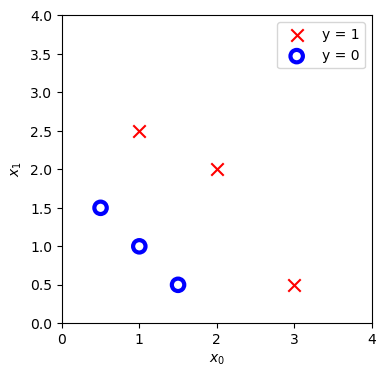

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (4,4))
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")
plt.show()

# Logistic Gradient Descent
Gradient Descent algorithm utilizes the following gradient calculation:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$
where each iteration performs simultaneous updates on $w_j$ for all j where

$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$
where,
* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target
* For a logistic regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   
    

In [20]:
def compute_gradient_logistic(X, y, w, b):
    """
    computes the gradient for logistic regression
    Args:
        X (ndarray (m, n)) : data, m examples with n features
        y (ndarray (m, )) : target values
        w (ndarray (n, )) : model parameter
        b (scalar) : model parameter
    Returns:
        dj_dw (ndarray (n, )) : the gradient of the cost w.r.t. the parameters w
        dj_dw (scalar) : the gradient of the cost w.r.t. the parameter b
    """
    m, n = X.shape
    dj_dw = np.zeros((n, ))
    dj_db = 0
    for i in range (m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw += err_i * X[i, j]
        dj_db += err_i
    dj_dw /= m
    dj_db /= m

    return dj_db, dj_dw

In [21]:
#checking the implementation of gradient descent
X_tmp = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2., 3.])
b_tmp = 1
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, b_tmp)
print(f"dj_dw: {dj_dw_tmp}")
print(f"dj_db: {dj_db_tmp}")

dj_dw: [0.99717282 0.99717282]
dj_db: 0.49861806546328574


# Gradient Descent Code

In [23]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """
    Performs batch gradient descent
    Args:
        X (ndarray (m, n)) : data, m examples with n features
        y (ndarray (m, )) : target values
        w_in (ndarray (n, )) : initial values of model parameters
        b_in (scalar) : initial values of model parameters
        alpha (scalar, float) : Learning Rate
        num_iters (scalar) : no. of iterations to run gradient descent
    Returns: 
        w (ndarray (n, )) : Updated values of parameters
        b (scalar) : Updated values of parameters
     """
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range (num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i < 100000:
            J_history.append(compute_cost_logistic(X, y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i : 4d}: Cost {J_history[-1]}")
    return w, b, J_history

In [25]:
#running gradient descent
w_tmp = np.zeros_like(X_train[0])
b_tmp = 0
alpha = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alpha, iters)
print(f"\nupdated parameters: w : {w_out}, b : {b_out}")

Iteration    0: Cost 0.6776833627571452
Iteration  1000: Cost 0.1455531827027191
Iteration  2000: Cost 0.07649164019776794
Iteration  3000: Cost 0.05139255824162284
Iteration  4000: Cost 0.03858471692722778
Iteration  5000: Cost 0.03085004080989656
Iteration  6000: Cost 0.025683081110997246
Iteration  7000: Cost 0.02199121007117215
Iteration  8000: Cost 0.01922341201538782
Iteration  9000: Cost 0.017072197258406484

updated parameters: w : [5.3497607 5.3497607], b : -14.648237107471077


# Plotting the results of gradiemt descent

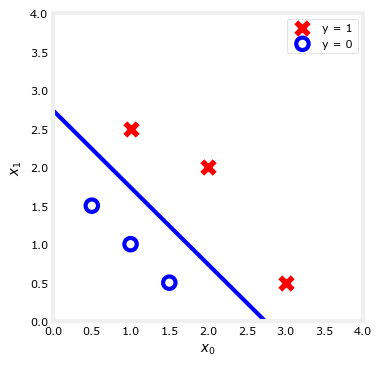

In [30]:
plt.close('all')
fig, ax = plt.subplots(1, 1, figsize = (4,4))
#plt_prob(ax, w_out, b_out) #plotting probability

#plotting original data
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")

#plotting desicion boundary
x0 = -b_out / w_out[0]
x1 = -b_out / w_out[1]
ax.plot([0, x0], [x1, 0], c = 'b', lw = 3)
plt.show()